<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Draft_ALS_to_GEDI_DL_Mode_W_SpatialAutoCorr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_GEDI_Data_New_Site

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_GEDI_Data_New_Site


In [ ]:
# %cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/GEDI_DEV_GUAN

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/GEDI_DEV_GUAN


In [ ]:
!ls

als_to_gedi_treeheight_model.pth
bounding_box.geojson
GEDI02_A_2019246042645_O04104_02_T00259_02_003_02_V002.h5
GEDI02_A_2020104212032_O07573_03_T01382_02_003_01_V002.h5
GEDI02_A_2020209182349_O09199_02_T03105_02_003_01_V002.h5
GEDI02_A_2020272172956_O10175_02_T05951_02_003_02_V002.h5
GEDI02_A_2020273024726_O10181_03_T07074_02_003_02_V002.h5
GEDI02_A_2020277011506_O10242_03_T08344_02_003_02_V002.h5
GEDI02_A_2020292190038_O10486_03_T08497_02_003_02_V002.h5
GEDI02_A_2021214154242_O14948_02_T01835_02_003_02_V002.h5
GEDI02_A_2021270173239_O15817_02_T03105_02_003_02_V002.h5
GEDI02_A_2021275011732_O15884_03_T08497_02_003_02_V002.h5
GEDI02_A_2022081195248_O18547_02_T08797_02_003_03_V002.h5
GEDI02_A_2022082051002_O18553_03_T04228_02_003_02_V002.h5
GEDI02_A_2022154150317_O19676_02_T05951_02_003_02_V002.h5
GEDI02_A_2022155002024_O19682_03_T01382_02_003_02_V002.h5
GEDI02_A_2022189012541_O20210_02_T00259_02_003_03_V002.h5
GEDI02_A_2022295163926_O21864_03_T05651_02_003_02_V002.h5
GEDI02_A_202306810

In [ ]:
df = pd.read_csv("GEDI_spatially_merged.csv")#"gedi_als_spatially_joined_within_25m.csv")  # Should have both ALS features and GEDI heights


# features = df.drop(columns=["rh98", "beam", "shot_number", "distance"]).values ## keeps Lidar_z
# targets = df["rh98"].values

#X = df.drop(columns=["rh98", "beam", "shot_number", "distance"]).values ## keeps Lidar_z
#y = df["rh98"].values


X = df["Lidar_z"].values
# print("X", X)
X = X.reshape(-1, 1)
print(X.shape)


y = df["rh98_GEDI2A"].values
# print("y", y)
y = y.reshape(-1, 1)
print(y.shape)


(1050328, 1)
(1050328, 1)


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

xxx

In [ ]:
df = pd.read_csv("GEDI_spatially_merged.csv")

# X = df[["Longitude", "Latitude", "Lidar_z"]]
# # print("X", X)
# # X = X.reshape(-1, 1)
# print(X)

# y = df[["Longitude", "Latitude", "rh98_GEDI2A"]]
# # print("y", y)
# # y = y.reshape(-1, 1)
# print(y)

# # Assuming X is a DataFrame with 'latitude' and 'longitude' columns
# data = X.copy()
# data['y'] = y

# print(data['y'])

data = df[["Longitude", "Latitude", "Lidar_z", "rh98_GEDI2A"]]
print(data)

         Longitude   Latitude  Lidar_z  rh98_GEDI2A
0       -66.856400  17.958028    20.24         0.86
1       -66.856400  17.958028    19.74         0.86
2       -66.856400  17.958028    21.22         0.86
3       -66.856400  17.958028    19.77         0.86
4       -66.856400  17.958028    19.94         0.86
...            ...        ...      ...          ...
1050323 -66.847367  17.954920    23.52         6.08
1050324 -66.847367  17.954920    23.64         6.08
1050325 -66.847367  17.954920    23.95         6.08
1050326 -66.847367  17.954920    24.55         6.08
1050327 -66.847367  17.954920    25.13         6.08

[1050328 rows x 4 columns]


In [ ]:
# 🧭 Create spatial bins (grid size in degrees)
lat_bins = np.linspace(data['Latitude'].min(), data['Latitude'].max(), num=20)
lon_bins = np.linspace(data['Longitude'].min(), data['Longitude'].max(), num=20)

data['lat_bin'] = np.digitize(data['Latitude'], lat_bins)
data['lon_bin'] = np.digitize(data['Longitude'], lon_bins)

# Unique spatial bins
data['spatial_bin'] = data['lat_bin'].astype(str) + "_" + data['lon_bin'].astype(str)
unique_bins = data['spatial_bin'].unique()
np.random.seed(42)
np.random.shuffle(unique_bins)

In [ ]:
# 🎯 Split the spatial bins
n_total_bins = len(unique_bins)
n_train = int(n_total_bins * 0.70)
n_test = int(n_total_bins * 0.20)
n_val = n_total_bins - n_train - n_test

train_bins = unique_bins[:n_train]
test_bins = unique_bins[n_train:n_train + n_test]
val_bins = unique_bins[n_train + n_test:]

train_bins ['18_12' '13_4' '7_7' '17_11' '7_8' '11_7' '7_16' '20_1' '10_5' '6_9'
 '15_9' '8_18' '19_1' '5_12' '1_14' '17_1' '15_7' '10_4' '11_19' '10_8'
 '4_13' '7_9' '15_8' '6_10' '3_12' '5_14' '6_2' '6_16' '5_9' '4_15' '9_3'
 '18_9' '16_3' '5_1' '8_17' '14_1' '8_8' '7_3' '8_2' '3_13' '10_19'
 '19_13' '13_5' '12_5' '12_6' '19_10' '14_9' '9_5' '2_12' '17_9' '8_4'
 '5_8' '10_6' '18_11' '6_15' '12_20' '9_19' '1_12' '6_8' '15_4' '7_17'
 '9_7' '18_2' '12_3' '5_10' '1_1' '14_3' '1_13' '13_8' '6_11' '11_6' '8_9'
 '13_6' '14_7' '6_7' '11_3' '18_1' '15_1' '15_3' '14_6' '11_5']
test_bins ['17_2' '1_15' '16_10' '3_10' '13_2' '6_1' '4_9' '10_18' '6_3' '7_2'
 '2_11' '16_8' '17_3' '12_7' '4_1' '7_11' '16_2' '8_6' '3_14' '15_2'
 '5_15' '14_5' '9_8']
val_bins ['2_14' '9_17' '10_7' '14_4' '17_10' '2_13' '1_11' '7_15' '2_15' '4_11'
 '13_3' '11_4' '9_9']


In [ ]:
# Assign samples
data['split'] = 'none'
data.loc[data['spatial_bin'].isin(train_bins), 'split'] = 'train'
data.loc[data['spatial_bin'].isin(test_bins), 'split'] = 'test'
data.loc[data['spatial_bin'].isin(val_bins), 'split'] = 'validation'



<ipython-input-26-3a1957b0ded8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['split'] = 'none'


In [ ]:
# Separate sets
train_data = data[data['split'] == 'train']
test_data = data[data['split'] == 'test']
val_data = data[data['split'] == 'validation']

# X_train = train_data.drop(columns=['rh98_GEDI2A', 'lat_bin', 'lon_bin', 'spatial_bin', 'split'])
X_train = train_data['Lidar_z']
X_train = X_train.values.reshape(-1, 1)
y_train = train_data['rh98_GEDI2A']
y_train = y_train.values.reshape(-1, 1)
# X_test = test_data.drop(columns=['rh98_GEDI2A', 'lat_bin', 'lon_bin', 'spatial_bin', 'split'])
X_test = test_data['Lidar_z']
X_test = X_test.values.reshape(-1, 1)
y_test = test_data['rh98_GEDI2A']
y_test = y_test.values.reshape(-1, 1)
# X_validation = val_data.drop(columns=['rh98_GEDI2A', 'lat_bin', 'lon_bin', 'spatial_bin', 'split'])
X_validation = val_data['Lidar_z']
X_validation = X_validation.values.reshape(-1, 1)
y_validation = val_data['rh98_GEDI2A']
y_validation = y_validation.values.reshape(-1, 1)

print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)
print("X_validation", X_validation.shape)
print("y_validation", y_validation.shape)

X_train (743204, 1)
y_train (743204, 1)
X_test (199343, 1)
y_test (199343, 1)
X_validation (107781, 1)
y_validation (107781, 1)


In [ ]:
# 🧪 Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_validation_scaled = scaler.transform(X_validation)

In [ ]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

X_validation_tensor = torch.tensor(X_validation, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation, dtype=torch.float32).view(-1, 1)

# Dataset and loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
#print("train_loader", vars(train_loader))

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=True)

In [ ]:
####all of this works in v1
# # Scale features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # print(X_scaled)


# ## works
# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# # Convert to tensors
# X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
# X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# # Dataset and loader
# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# #print("train_loader", vars(train_loader))

# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [ ]:
class TreeHeightRegressor(nn.Module):
    def __init__(self, input_dim):
        super(TreeHeightRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = TreeHeightRegressor(X_train.shape[1])


In [ ]:
epochs = 10
learning_rate = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch 000 | Train Loss: 100.7886 | Test Loss: 171.6418
Epoch 001 | Train Loss: 99.6268 | Test Loss: 146.2642
Epoch 002 | Train Loss: 99.4739 | Test Loss: 150.9165
Epoch 003 | Train Loss: 99.3903 | Test Loss: 156.7461
Epoch 004 | Train Loss: 99.3912 | Test Loss: 154.2328
Epoch 005 | Train Loss: 99.3591 | Test Loss: 154.9679
Epoch 006 | Train Loss: 99.3526 | Test Loss: 150.6241
Epoch 007 | Train Loss: 99.3341 | Test Loss: 154.2189
Epoch 008 | Train Loss: 99.3300 | Test Loss: 151.9359
Epoch 009 | Train Loss: 99.2870 | Test Loss: 153.3425


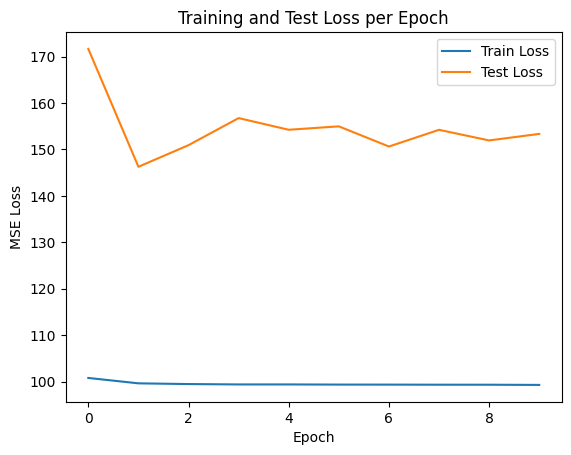

In [ ]:
import matplotlib.pyplot as plt

# Initialize live plotting
plt.ion()
fig, ax = plt.subplots()
train_losses, test_losses = [], []
train_line, = ax.plot([], [], label='Train Loss')
test_line, = ax.plot([], [], label='Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training and Test Loss per Epoch')
ax.legend()
fig.canvas.draw()
fig.show()

# Training loop
for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()
        test_losses.append(test_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # Update the plot
    train_line.set_data(range(len(train_losses)), train_losses)
    test_line.set_data(range(len(test_losses)), test_losses)
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw()
    fig.canvas.flush_events()

# Final plot
plt.ioff()
plt.show()


In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Helper to evaluate a DataLoader
def evaluate_loader(model, loader, name):
    model.eval()
    y_preds = []
    y_trues = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            y_preds.append(y_pred)
            y_trues.append(y_batch)

    # Concatenate all batches
    y_pred_all = torch.cat(y_preds).numpy()
    y_true_all = torch.cat(y_trues).numpy()

    # Flatten arrays for sklearn metrics
    y_pred_all = y_pred_all.flatten()
    y_true_all = y_true_all.flatten()

    # Compute metrics
    mse = mean_squared_error(y_true_all, y_pred_all)
    mae = mean_absolute_error(y_true_all, y_pred_all)
    r2 = r2_score(y_true_all, y_pred_all)

    print(f"\n{name} Set Performance:")
    print(f"  RMSE: {np.sqrt(mse):.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")

# Example use after training your PyTorch model
evaluate_loader(model, train_loader, "Train")
evaluate_loader(model, test_loader, "Test")
evaluate_loader(model, validation_loader, "Validation")



Train Set Performance:
  RMSE: 9.9607
  MAE:  5.2431
  R²:   0.0392

Test Set Performance:
  RMSE: 12.3832
  MAE:  7.3459
  R²:   -0.0741

Validation Set Performance:
  RMSE: 5.0248
  MAE:  4.5169
  R²:   -2.0791


In [ ]:
# model.eval()
# with torch.no_grad():
#     predictions = model(X_test_tensor)
#     test_loss = criterion(predictions, y_test_tensor)
#     mae = torch.mean(torch.abs(predictions - y_test_tensor))

# print(f"\nTest MSE: {test_loss.item():.4f}")
# print(f"Test MAE: {mae.item():.2f}")



Test MSE: 153.3425
Test MAE: 7.35


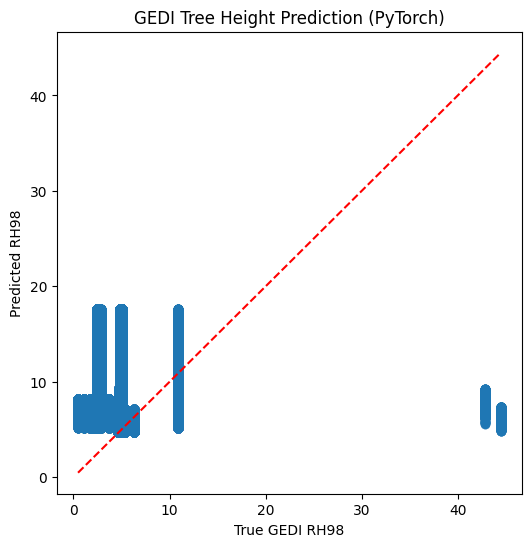

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_tensor.numpy(), predictions.numpy(), alpha=0.5)
plt.xlabel('True GEDI RH98')
plt.ylabel('Predicted RH98')
plt.title('GEDI Tree Height Prediction (PyTorch)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()


In [ ]:
# ---------- Save the Model ----------
torch.save(model.state_dict(), "als_to_gedi_treeheight_model.pth")